In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
%matplotlib inline

In [2]:
df = pd.read_csv("data/StudentsPerformance.csv")

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [5]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [6]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [7]:
print("categories in 'gender' column:", df['gender'].unique())
print("categories in 'race/ethnicity' column:", df['race/ethnicity'].unique())
print("categories in 'parental level of education' column:", df['parental level of education'].unique())
print("categories in 'lunch' column:", df['lunch'].unique())
print("categories in 'test preparation course' column:", df['test preparation course'].unique())

categories in 'gender' column: ['female' 'male']
categories in 'race/ethnicity' column: ['group B' 'group C' 'group A' 'group D' 'group E']
categories in 'parental level of education' column: ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
categories in 'lunch' column: ['standard' 'free/reduced']
categories in 'test preparation course' column: ['none' 'completed']


In [8]:
numerical_features = [nf for nf in df.columns if df[nf].dtype != 'O']
print("Numerical Features: ",numerical_features)
cat_features = [catf for catf in df.columns if df[catf].dtype == 'O']
print("Categorical Features: ",cat_features)

Numerical Features:  ['math score', 'reading score', 'writing score']
Categorical Features:  ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.head(3)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93


### Feature Engineering

In [12]:
df['Total Score'] = df['math score'] + df['reading score'] + df['writing score']

In [13]:
df['Average'] = df['Total Score'] / 3

In [14]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [15]:
full_marks_math = df[df['math score'] == 100]['Average'].count()
full_marks_reading = df[df['reading score'] == 100]['Average'].count()
full_marks_writing = df[df['writing score'] == 100]['Average'].count()

print(f"Number of students with full marks in Math: {full_marks_math}")
print(f"Number of students with full marks in Reading: {full_marks_reading}")
print(f"Number of students with full marks in Writing: {full_marks_writing}")

Number of students with full marks in Math: 7
Number of students with full marks in Reading: 17
Number of students with full marks in Writing: 14


## Data Visualization

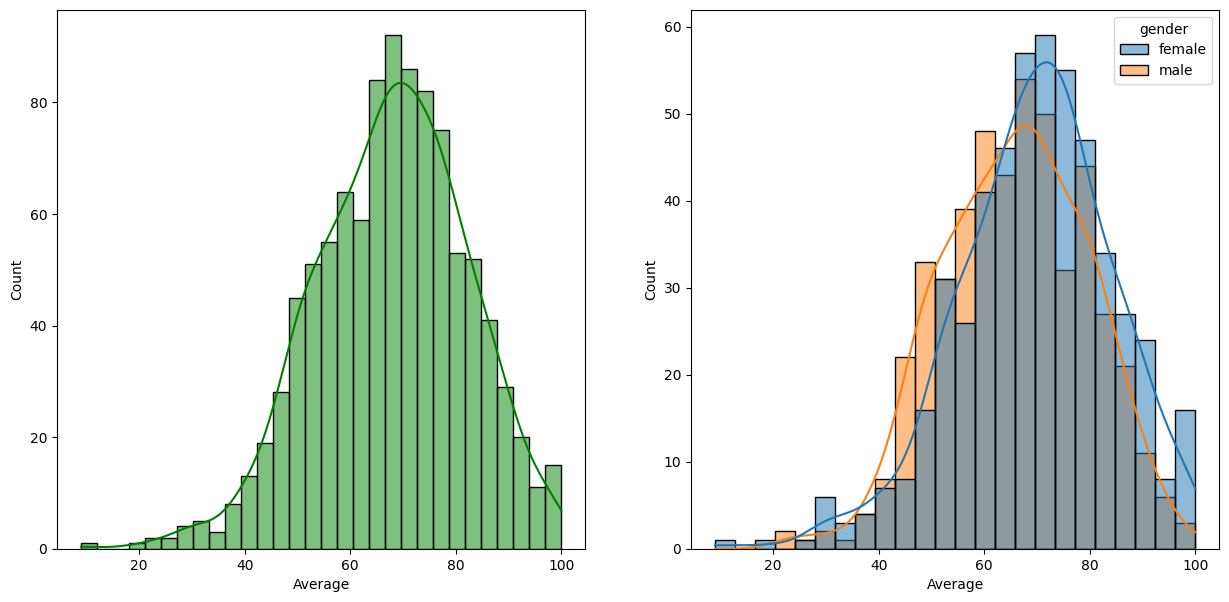

In [16]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.histplot(data=df, x='Average', bins=30, kde=True, color='g')

plt.subplot(122)
sns.histplot(data=df, x='Average', kde=True, hue='gender')

plt.show()

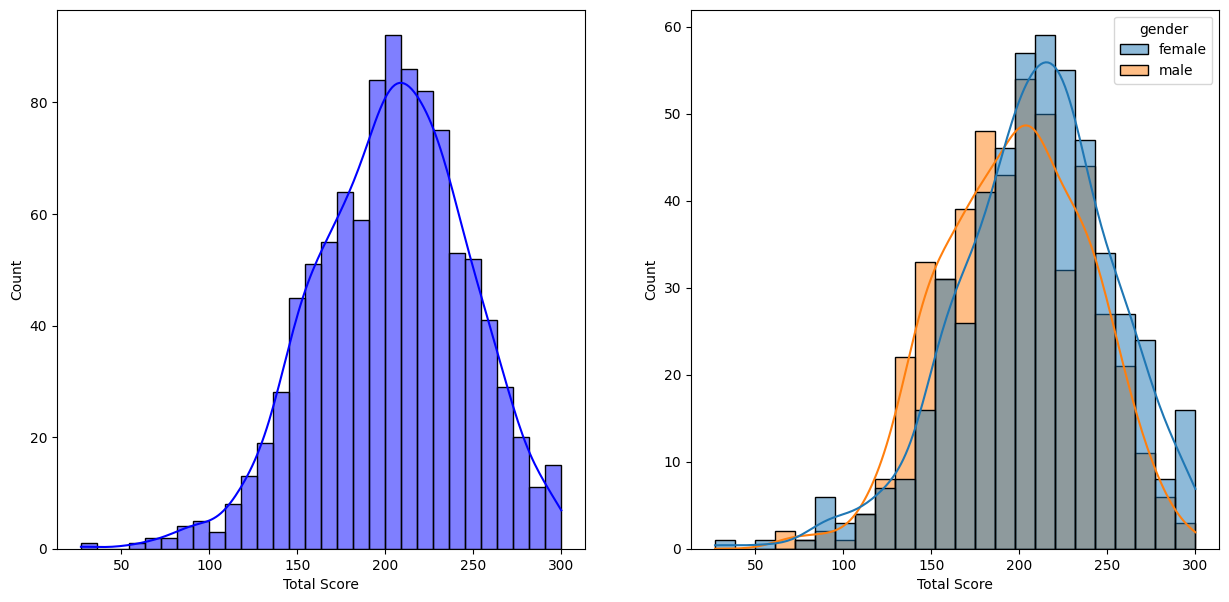

In [17]:
fig, axs = plt.subplots(1, 2, figsize=(15, 7))

plt.subplot(121)
sns.histplot(data=df, x='Total Score', bins=30, kde=True, color='b')

plt.subplot(122)
sns.histplot(data=df, x='Total Score', kde=True, hue='gender')

plt.show()

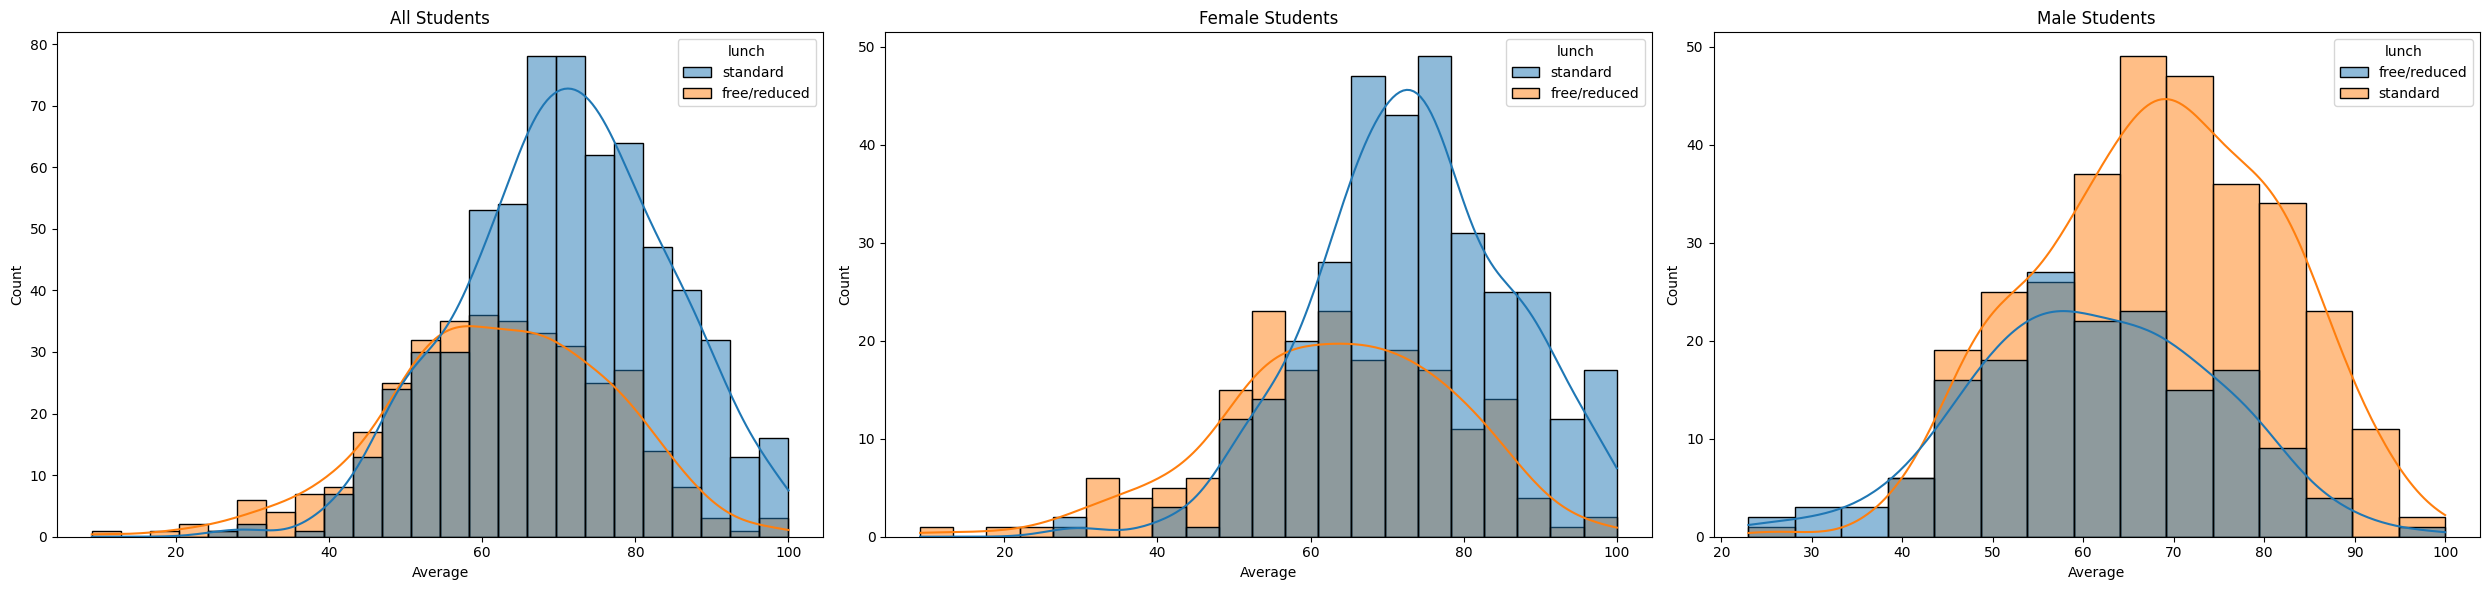

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(25, 6))

sns.histplot(data=df, x='Average', kde=True, hue='lunch', ax=axes[0])
axes[0].set_title('All Students')

sns.histplot(data=df[df.gender=='female'],
             x='Average', kde=True, hue='lunch', ax=axes[1])
axes[1].set_title('Female Students')

sns.histplot(data=df[df.gender=='male'],
             x='Average', kde=True, hue='lunch', ax=axes[2])
axes[2].set_title('Male Students')

plt.tight_layout()
plt.show()

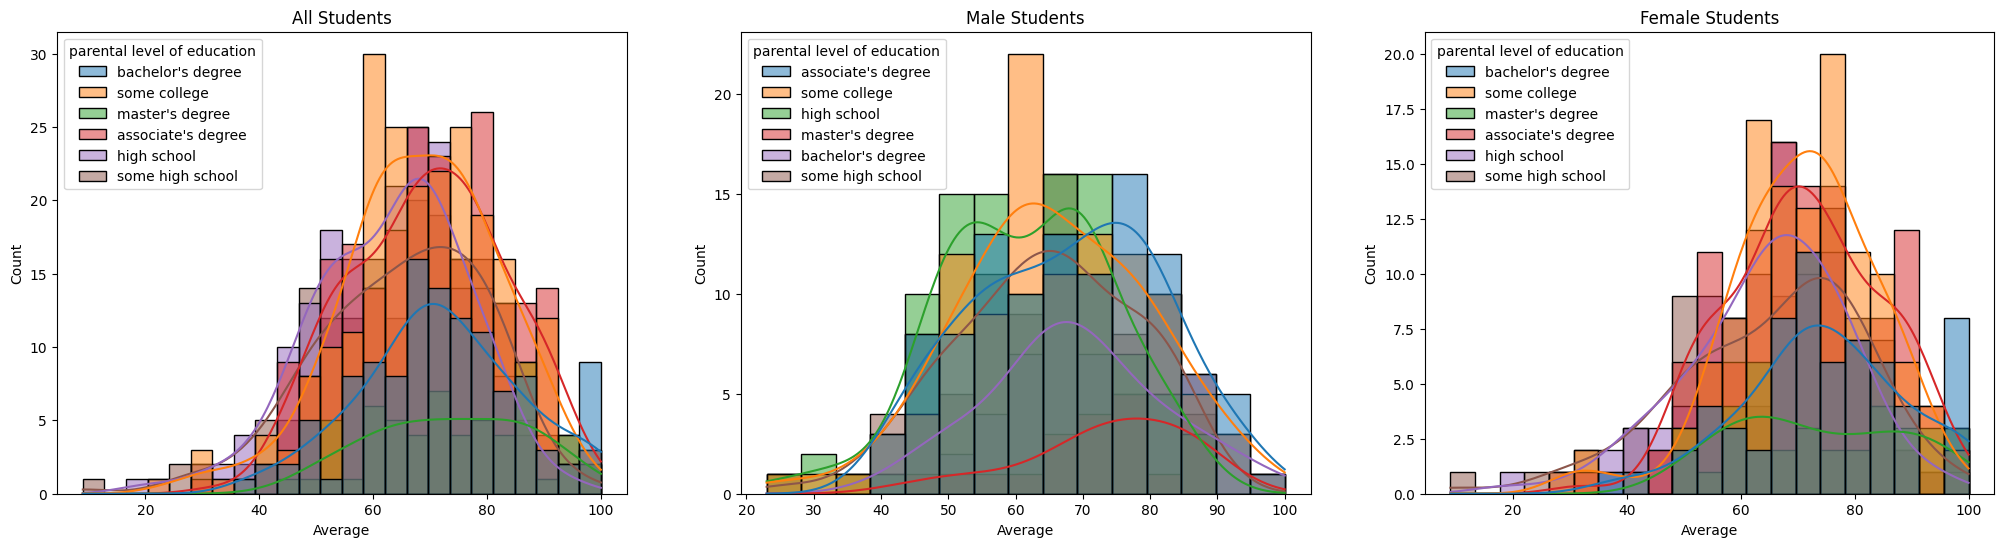

In [19]:
fig, axes = plt.subplots(1,3, figsize=(25,6))

ax =sns.histplot(data=df, x='Average', kde=True, hue='parental level of education', ax=axes[0])
axes[0].set_title("All Students")

ax =sns.histplot(data=df[df.gender=='male'], x='Average', kde=True, hue='parental level of education', ax=axes[1])
axes[1].set_title("Male Students")

ax =sns.histplot(data=df[df.gender=='female'], x='Average', kde=True, hue='parental level of education', ax=axes[2])
axes[2].set_title("Female Students")

plt.show()

### Maximum score of students in all three subjects

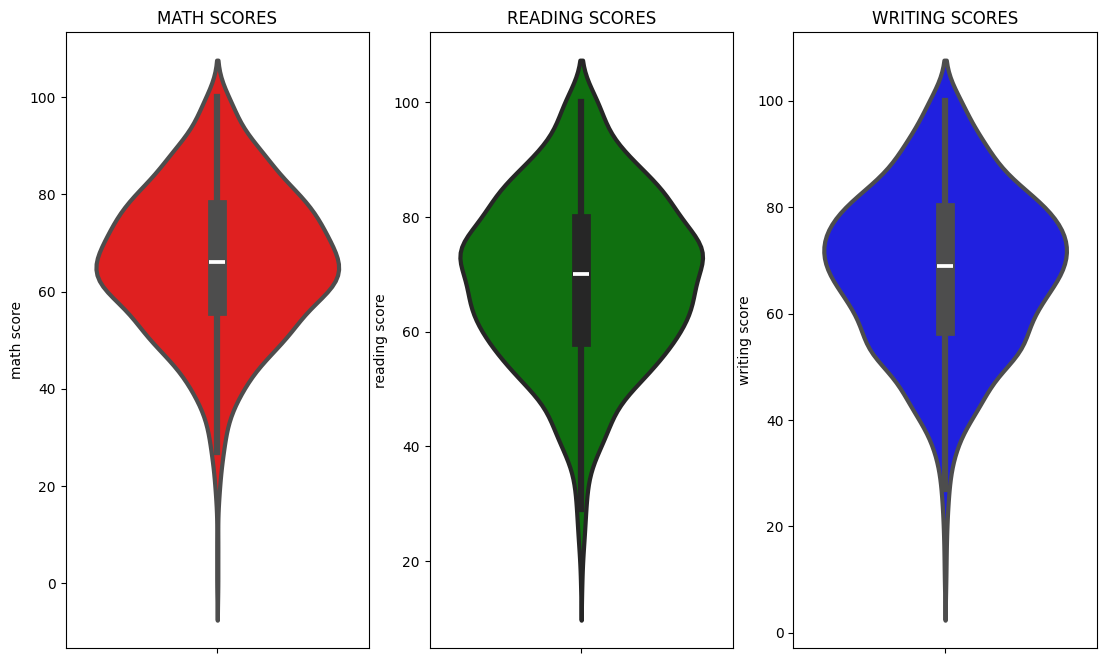

In [20]:
plt.figure(figsize=(18,8))

plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math score', data=df, color='red', linewidth=3)

plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading score', data=df, color='green', linewidth=3)

plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing score', data=df, color='blue', linewidth=3)

plt.show()

### Multivariate Analysis

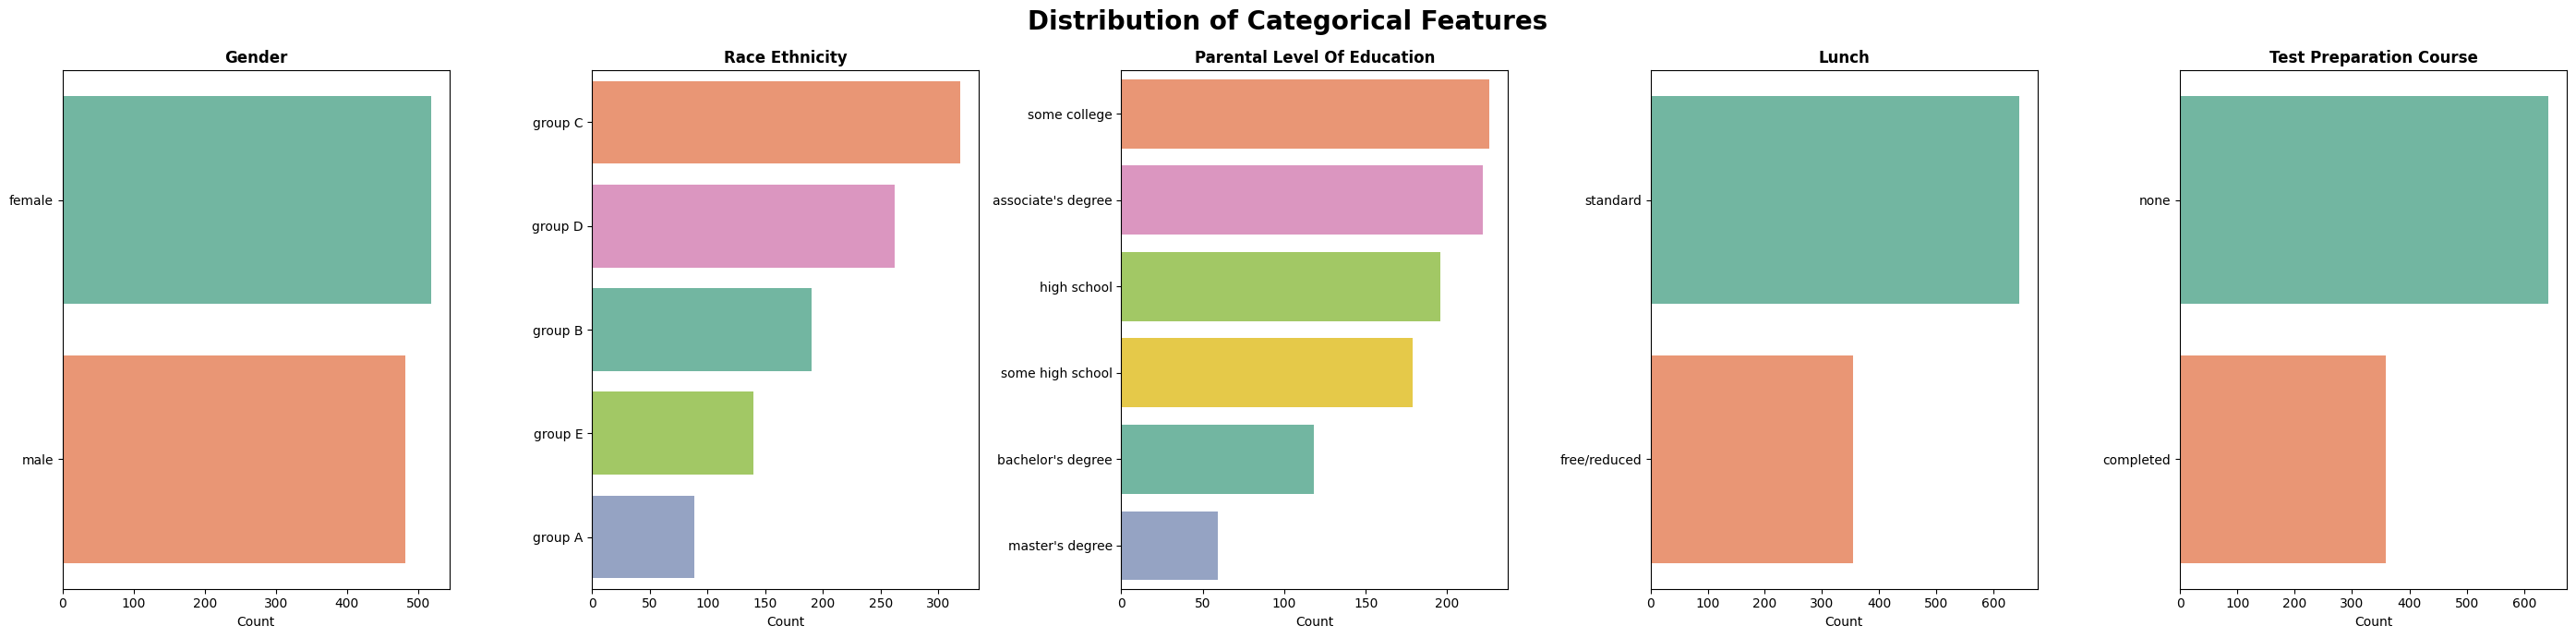

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = [
    'gender',
    'race/ethnicity',
    'lunch',
    'test preparation course',
    'parental level of education'
]

fig, axes = plt.subplots(1, 5, figsize=(28, 7))

for ax, col in zip(axes, cat_features):

    sns.countplot(
        data=df,
        y=col,
        hue=col,
        palette='Set2',
        legend=False,
        order=df[col].value_counts().index,
        ax=ax
    )

    ax.set_title(col.replace('/', ' ').title(),
                 fontsize=12,
                 fontweight='bold')

    ax.set_xlabel('Count')
    ax.set_ylabel('')

plt.suptitle(
    'Distribution of Categorical Features',
    fontsize=20,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Feature wise visualization

#### Univariate Analysis (How is distribution of Gender?)

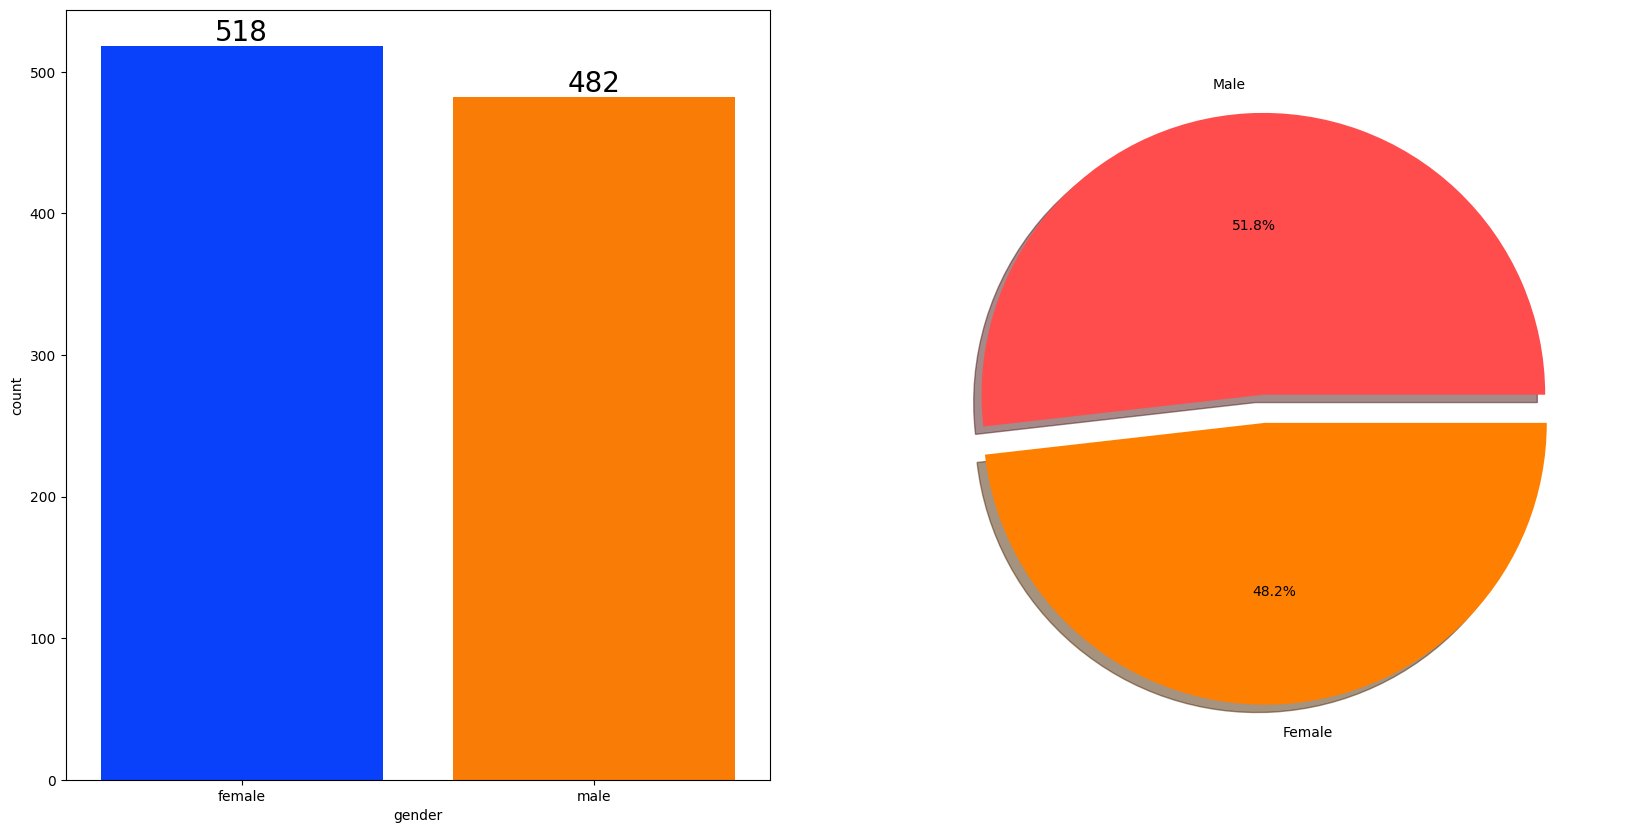

In [22]:
f,ax=plt.subplots(1,2,figsize=(20,10))

sns.countplot(data=df, x='gender', hue = 'gender', palette ='bright', ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container,color='black',size=20)
    
plt.pie(x=df['gender'].value_counts(),
        labels=['Male','Female'], explode=[0,0.1], 
        autopct='%1.1f%%', shadow=True, colors=['#ff4d4d','#ff8000'])

plt.show()

#### Bivariate Analysis (Is gender has any impact on student's performance?)

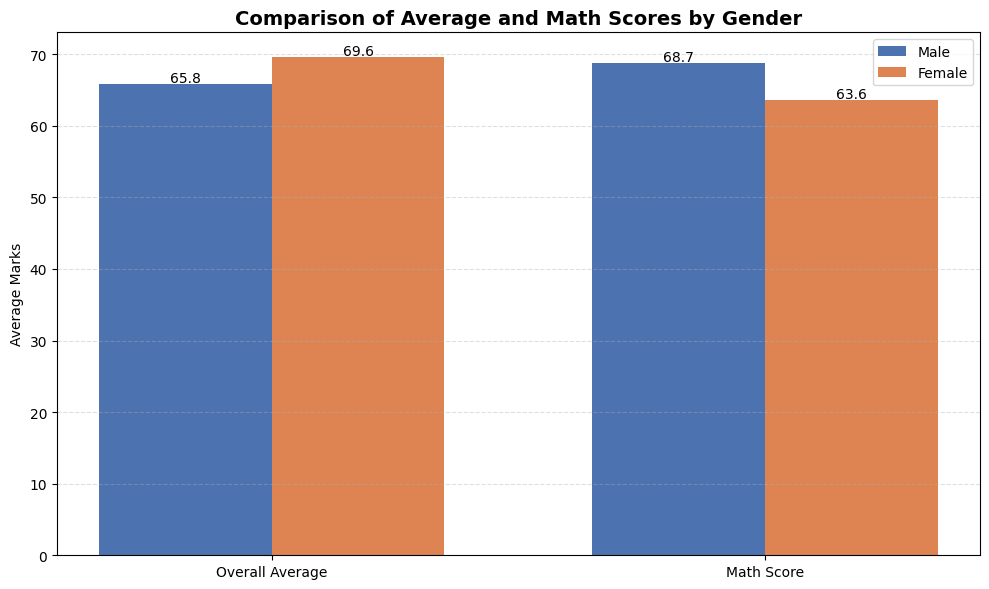

In [23]:
gender_group = df.groupby('gender').mean(numeric_only=True)

categories = ['Overall Average', 'Math Score']

male_scores = [
    gender_group.loc['male', 'Average'],
    gender_group.loc['male', 'math score']
]

female_scores = [
    gender_group.loc['female', 'Average'],
    gender_group.loc['female', 'math score']
]

x = np.arange(len(categories))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

bars1 = ax.bar(
    x - width/2,
    male_scores,
    width,
    label='Male',
    color='#4C72B0'
)

bars2 = ax.bar(
    x + width/2,
    female_scores,
    width,
    label='Female',
    color='#DD8452'
)

# Add labels
for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{bar.get_height():.1f}',
            ha='center'
        )

ax.set_xticks(x)
ax.set_xticklabels(categories)

ax.set_ylabel('Average Marks')
ax.set_title(
    'Comparison of Average and Math Scores by Gender',
    fontsize=14,
    fontweight='bold'
)

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

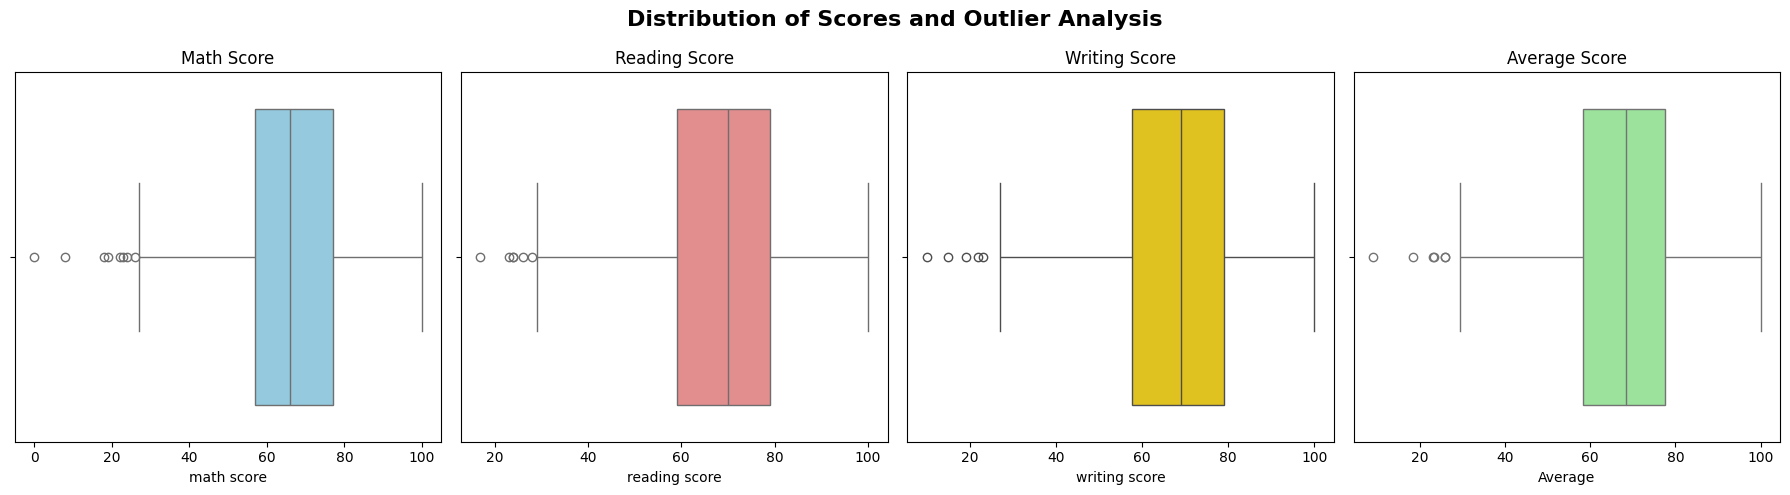

In [24]:
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sns.boxplot(x=df['math score'], color='skyblue', ax=axes[0])
axes[0].set_title('Math Score')

sns.boxplot(x=df['reading score'], color='lightcoral', ax=axes[1])
axes[1].set_title('Reading Score')

sns.boxplot(x=df['writing score'], color='gold', ax=axes[2])
axes[2].set_title('Writing Score')

sns.boxplot(x=df['Average'], color='lightgreen', ax=axes[3])
axes[3].set_title('Average Score')

fig.suptitle(
    'Distribution of Scores and Outlier Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### 5. Conclusions
- Student's Performance is related with lunch, race, parental level education
- Females lead in pass percentage and also are top-scorers
- Student's Performance is not much related with test preparation course
- Finishing preparation course is benefitial.